## MECHA

### Computing the root hydraulic properties

MECHA is an explicit cross-section model of the root hydraulic anatomy which connects hydraulic concepts across scales.

### Run MECHA


In [1]:
%cd ..

/mnt/c/Users/adhs0001/Documents/GitHub/MECHA-dev


In [3]:
from main import *

#Directory
dir = './'

#Project
Project ='Projects/test/' 

#Inputs
inputs='in/'
Gen='General.xml'
Geom='Geometry.xml'
Hydr='Hydraulics.xml'
BC='BC.xml'
Horm='Hormones_Carriers.xml'

# Run MECHA
MECHA_run(dir, Project)

Importing Data
InterCid #-1 excluded
0.5338052489996699 seconds process time
Initializing network
Identifying soil-root interface walls
Getting X and Y cell nodes
0.5745929820000129 seconds process time
Creating network connections
3.6050354599997263 seconds process time
Computing cortex AQP parameters
0.03851039000028322 seconds process time


/mnt/c/Users/adhs0001/Documents/GitHub/MECHA-dev/main.py:466: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ThickWalls.append(array((twpid,wid,cid,x,y,inf,inf,Borderlink[wid]))) #Adds the thick wall node ID, its parent node ID, the associated cell ID, the new coordinates in X and Y, and the two neighbouring new junction walls IDs (not known at this point in the loop)     G.node[i]['borderlink']
/mnt/c/Users/adhs0001/Documents/GitHub/MECHA-dev/main.py:614: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ThickWalls.append(array((twpid,j,int(cid),x,y,twpi

Maturity #0 with apoplastic barrier type #0
Maturity #1 with apoplastic barrier type #1
Maturity #2 with apoplastic barrier type #2
3.6962469410000267 seconds process time


### Make plot of the partitioning

In [8]:
file_path = dir+Project+"out/Tomato/Root/Project_Test/results/Macro_prop_1,1.txt"


# Open and read the file
with open(file_path, "r") as file:
    # Read the contents of the file
    fl = file.read()
    
Hydr = Macro_hydro_visu(fl)    


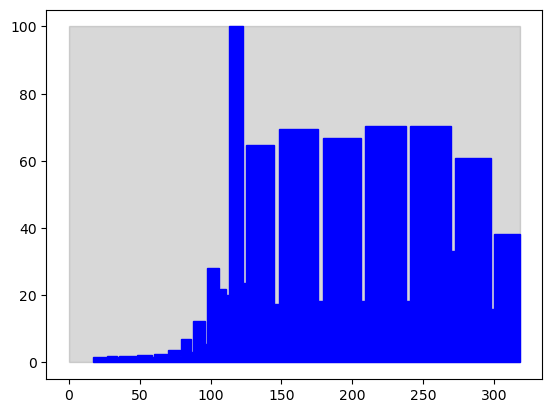

In [9]:
info = {'STUF' : Hydr.STFlayer_plus,
        'STRF' : Hydr.STFlayer_minus, 
        'dist' : Hydr.Layer_dist2,
        'type' : Hydr.cell_type}
df = pd.DataFrame(data = info)
df = df[::-1].reset_index(drop=True)
df['STF diff'] = df['STUF']-df['STRF']
df['STF'] = df['STF diff'].cumsum()
df['cell_spacing'] = df['dist'].diff()

poly = Macro_hydro_visu.poly_table(df)
Macro_hydro_visu.graph_apo_symp(poly)

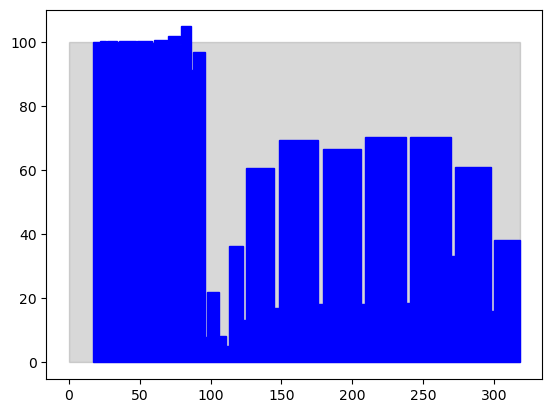

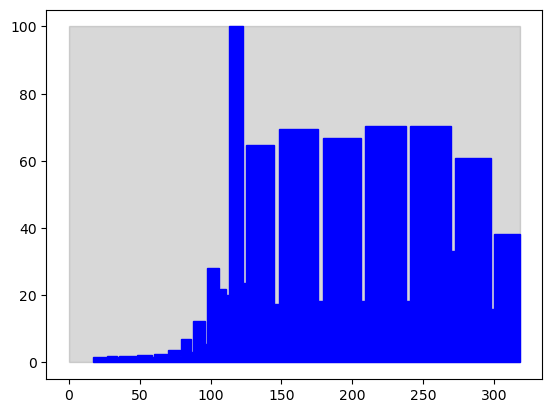

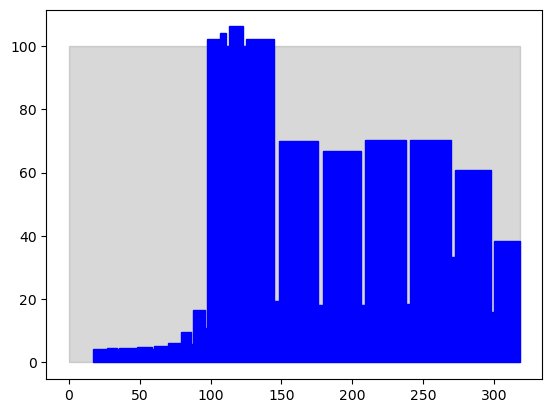

In [13]:
# Set the folder path where the .txt files are located
folder_path = os.path.join(dir, Project, "out/Tomato/Root/Project_Test/results/")

# Loop through all .txt files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".txt") & file_name.startswith("Macro_prop"):  # Check if the Macro_prop file is a .txt file
        file_path = os.path.join(folder_path, file_name)  # Full path to the file
        
        # Open and read the file
        with open(file_path, "r") as file:
            # Read the contents of the file
            fl = file.read()
        
        # Call your plot function with the file content
        plot_partition(fl)